                            OLS Regression Results                            
Dep. Variable:       PREMIUM RATE (%)   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     5.564
Date:                Fri, 25 Jul 2025   Prob (F-statistic):           5.10e-15
Time:                        13:38:12   Log-Likelihood:                 802.13
No. Observations:                 176   AIC:                            -1506.
Df Residuals:                     127   BIC:                            -1351.
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0097    

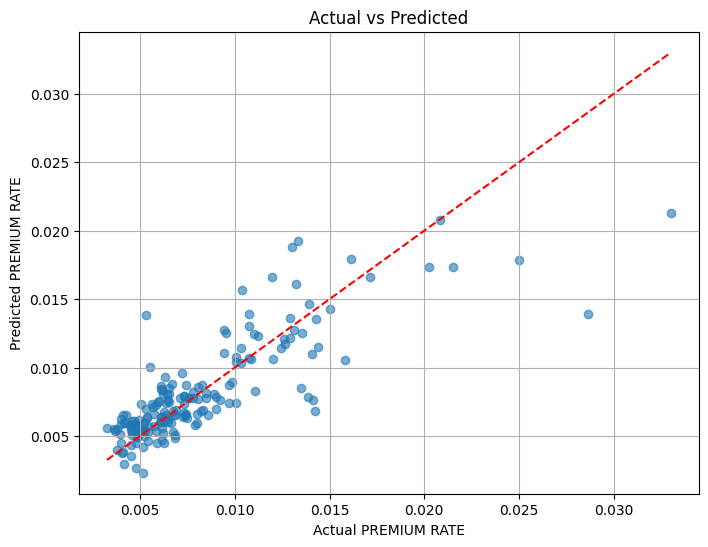

In [222]:
# Full Dataset Regression Model
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load Data
file_path = r"K:\Kmis_Public\Clare\PREMIUM REGRESSION\PRIMARY REGRESSION DATA.xlsx"
df = pd.read_excel(file_path, sheet_name="PRIMARY DATA")

# Prepare Data
df['DATE BOUND'] = pd.to_datetime(df['DATE BOUND'])
df['MONTH_BOUND'] = df['DATE BOUND'].dt.to_period('M').astype(str)
df['HAZARD_SCORE'] = df['FIRE SCORE'].astype(str)
df['LATITUDE'] = pd.to_numeric(df['LATITUDE'])
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'])

# Limit Bands
limit_bins = [0, 1e6, 5e6, 10e6, np.inf]
limit_labels = ['0-1M', '1-5M', '5-10M', '>10M']
df['TIV_BAND'] = pd.cut(df['PROPERTY LIMIT'], bins=limit_bins, labels=limit_labels)
df['COV_A_BAND'] = pd.cut(df['POLICY LIMIT - COV A'], bins=limit_bins, labels=limit_labels)

# Create X, Y
y = df_model['PREMIUM RATE (%)']
X_base = df_model[['LATITUDE', 'LONGITUDE']]
X_cat = pd.get_dummies(df_model[['HAZARD_SCORE', 'MONTH_BOUND', 'TIV_BAND', 'COV_A_BAND']], drop_first=False)
X = pd.concat([X_base, X_cat], axis=1)
X = sm.add_constant(X)
X = X.astype(float)

# Regression
model = sm.OLS(y, X).fit()
print(model.summary())

# Predict
y_pred = model.predict(X)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual PREMIUM RATE")
plt.ylabel("Predicted PREMIUM RATE")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Load Data
file_path = r"K:\Kmis_Public\Clare\PREMIUM REGRESSION\PRIMARY REGRESSION DATA.xlsx"
df = pd.read_excel(file_path, sheet_name="PRIMARY DATA")

# Prepare Data
df['DATE BOUND'] = pd.to_datetime(df['DATE BOUND'])
df['MONTH_BOUND'] = df['DATE BOUND'].dt.to_period('M').astype(str)
df['HAZARD_SCORE'] = df['FIRE SCORE'].astype(str)
df['LATITUDE'] = pd.to_numeric(df['LATITUDE'])
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'])

# Bands
limit_bins = [0, 1e6, 5e6, 10e6, np.inf]
limit_labels = ['0-1M', '1-5M', '5-10M', '>10M']
df['TIV_BAND'] = pd.cut(df['PROPERTY LIMIT'], bins=limit_bins, labels=limit_labels)
df['COV_A_BAND'] = pd.cut(df['POLICY LIMIT - COV A'], bins=limit_bins, labels=limit_labels)

In [224]:
# One80 Policies
one80_list = [
    "KSHOC000000351-00", "KSHOC000000340-00", "KSHOC000000319-00", "KSHOC000000321-00",
    "KSHOC000000317-00", "KSHOC000000293-00", "KSHOC000000292-00", "KSHOC000000288-00",
    "KSHOC000000280-00", "KSHOC000000275-00", "KSHOC000000267-00", "KSHOC000000266-00",
    "KSHOC000000251-00", "KSHOC000000249-00", "KSHOC000000244-00", "KSHOC000000245-00",
    "KSHOC000000241-00", "KSHOC000000232-00", "KSHOC000000226-00", "KSHOC000000227-00",
    "KSHOC000000217-00", "KSHOC000000218-00", "KSHOC000000204-00", "KSHOC000000205-00",
    "KSHOC000000199-00", "KSHOC00114", "KSHOC00107", "KSHOC00100", "KSHOC00109",
    "KSHOC00101", "KSHOC00092", "KSHOC00095", "KSHOC00086"
]

In [225]:
# Create 4 datasets
def create_dataset(exclude_month=False, exclude_one80=False):
    df_filtered = df.copy()
    if exclude_one80:
        df_filtered = df_filtered[~df_filtered['POLICY NUMBER'].isin(one80_list)]
    y = df_filtered['PREMIUM RATE (%)']
    X_base = df_filtered[['LATITUDE', 'LONGITUDE']]
    dummies_cols = ['HAZARD_SCORE', 'TIV_BAND', 'COV_A_BAND']
    if not exclude_month:
        dummies_cols.append('MONTH_BOUND')
    X_cat = pd.get_dummies(df_filtered[dummies_cols], drop_first=False)
    X = pd.concat([X_base, X_cat], axis=1)
    X = sm.add_constant(X)
    return X.astype(float), y, df_filtered

In [226]:
# Run all models
models = {}
labels = ['Full Data', 'No Monthly Variable', 'No One80', 'No One80 + No Monthly Variable']
for label, (drop_month, drop_one80) in zip(labels, [
    (False, False), (True, False), (False, True), (True, True)
]):
    X, y, df_use = create_dataset(drop_month, drop_one80)
    model = sm.OLS(y, X).fit()
    models[label] = model
    print(f"{label}")
    print("R-squared:", round(model.rsquared, 3))
    print(model.summary().tables[0], "\n")

Full Data
R-squared: 0.678
                            OLS Regression Results                            
Dep. Variable:       PREMIUM RATE (%)   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     5.606
Date:                Fri, 25 Jul 2025   Prob (F-statistic):           3.42e-15
Time:                        13:38:17   Log-Likelihood:                 807.02
No. Observations:                 177   AIC:                            -1516.
Df Residuals:                     128   BIC:                            -1360.
Df Model:                          48                                         
Covariance Type:            nonrobust                                         

No Monthly Variable
R-squared: 0.644
                            OLS Regression Results                            
Dep. Variable:       PREMIUM RATE (%)   R-squared:                

In [227]:
# Identify Outliers
model_full = models['Full Data']
X_full, y_full, df_full = create_dataset(False, False)
y_pred = model_full.predict(X_full)
resid_std = np.std(y_full - y_pred)

lower_bound = y_pred - 1.96 * resid_std
upper_bound = y_pred + 1.96 * resid_std
outliers_mask = (y_full < lower_bound) | (y_full > upper_bound)

outliers_df = df_full.loc[outliers_mask].copy()
outliers_df['Predicted PREMIUM RATE'] = y_pred[outliers_mask]
outliers_df['Residual'] = y_full[outliers_mask] - y_pred[outliers_mask]
outliers_df

,POLICY NUMBER,PREMIUM RATE (%),PLACEMENT,PROPERTY LIMIT,FIRE SCORE,BOUND PREMIUM,DATE BOUND,SYS TRACKING NUMBER,POLICY LIMIT - COV A,LONGITUDE,LATITUDE,MONTH_BOUND,HAZARD_SCORE,TIV_BAND,COV_A_BAND,Predicted PREMIUM RATE,Residual
38,KSHOC000000317-00,0.028627,PRIMARY,5000000,D-5,143135,2025-06-16,KSHOC000000317-00,4000000,-117.837210,33.592960,2025-06,D-5,1-5M,1-5M,0.013909,0.014718
41,KSHOC000000309-00,0.024987,PRIMARY,9700000,F-8,242375,2025-06-11,KSHOC000000309-00,8000000,-118.408800,34.096800,2025-06,F-8,5-10M,5-10M,0.017905,0.007082
75,KSHOC000000255-00,0.015797,PRIMARY,5257200,D-7,83050,2025-05-07,KSHOC000000255-00,4044000,-119.661810,34.437670,2025-05,D-7,5-10M,1-5M,0.010567,0.005230
97,KSHOC000000210-00,0.014228,PRIMARY,10000000,B-3,142282,2025-04-08,KSHOC000000210-01,10000000,-118.436470,34.086280,2025-04,B-3,5-10M,5-10M,0.006858,0.007370
99,KSHOC000000206-00,0.013864,PRIMARY,10000000,C-3,138635,2025-04-04,KSHOC000000206-01,10000000,-118.357570,34.104070,2025-04,C-3,5-10M,5-10M,0.007884,0.005979
100,KSHOC000000204-00,0.005316,PRIMARY,6700000,D-5,35620,2025-04-01,KSHOC000000204-01,5200000,-118.459340,34.080940,2025-04,D-5,5-10M,5-10M,0.013889,-0.008572
101,KSHOC000000205-00,0.010369,PRIMARY,4679200,F-8,48520,2025-04-01,KSHOC000000205-01,2576000,-118.601720,34.078700,2025-04,F-8,1-5M,1-5M,0.015672,-0.005303
103,KSHOC000000199-00,0.013333,PRIMARY,6000000,F-10,80000,2025-03-26,KSHOC000000199-01,5000000,-118.446840,34.090620,2025-03,F-10,5-10M,1-5M,0.019236,-0.005903
119,KSHOC00104,0.013508,PRIMARY,10000000,C-1,135075,2025-02-28,KSHOC00104,9000000,-118.801570,34.006320,2025-02,C-1,5-10M,5-10M,0.008529,0.004979
126,KSHOC00095,0.033000,PRIMARY,5000000,F-10,165000,2025-02-21,KSHOC00095,5000000,-118.463560,34.089430,2025-02,F-10,1-5M,1-5M,0.021287,0.011713


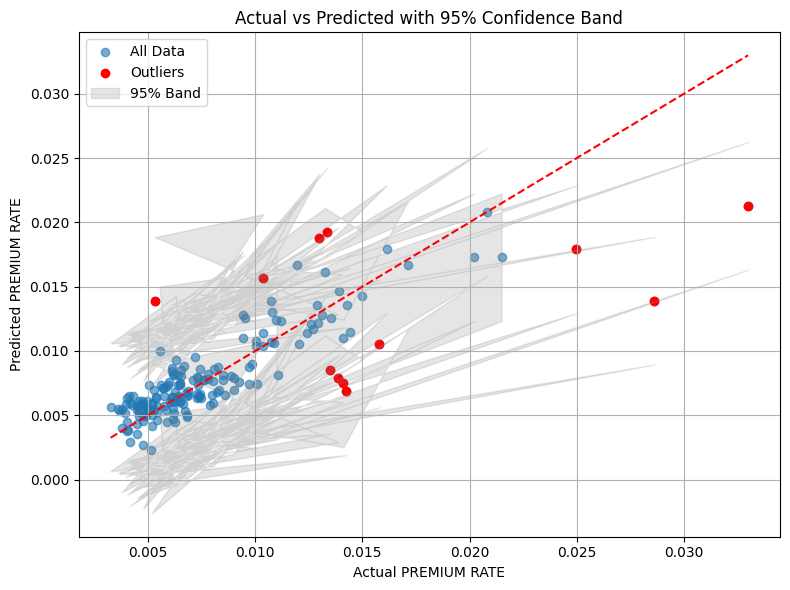

In [228]:
# Plot with 95% Band + Highlight Outliers
plt.figure(figsize=(8,6))
plt.scatter(y_full, y_pred, alpha=0.6, label='All Data')
plt.scatter(y_full[outliers_mask], y_pred[outliers_mask], color='red', label='Outliers')
plt.plot([y_full.min(), y_full.max()], [y_full.min(), y_full.max()], 'r--')
plt.fill_between(y_full, lower_bound, upper_bound, color='gray', alpha=0.2, label='95% Band')
plt.xlabel("Actual PREMIUM RATE")
plt.ylabel("Predicted PREMIUM RATE")
plt.title("Actual vs Predicted with 95% Confidence Band")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [229]:
# Rebuild model excluding One80
model_no_one80 = models['No One80']
X_no_one80, y_no_one80, df_no_one80 = create_dataset(False, True)
y_pred_no_one80 = model_no_one80.predict(X_no_one80)
resid_std_no_one80 = np.std(y_no_one80 - y_pred_no_one80)

# Identify Outliers
lower_bound_no_one80 = y_pred_no_one80 - 1.96 * resid_std_no_one80
upper_bound_no_one80 = y_pred_no_one80 + 1.96 * resid_std_no_one80
outliers_mask_no_one80 = (y_no_one80 < lower_bound_no_one80) | (y_no_one80 > upper_bound_no_one80)

outliers_df_no_one80 = df_no_one80.loc[outliers_mask_no_one80].copy()
outliers_df_no_one80['Predicted PREMIUM RATE'] = y_pred_no_one80[outliers_mask_no_one80]
outliers_df_no_one80['Residual'] = y_no_one80[outliers_mask_no_one80] - y_pred_no_one80[outliers_mask_no_one80]
outliers_df_no_one80

,POLICY NUMBER,PREMIUM RATE (%),PLACEMENT,PROPERTY LIMIT,FIRE SCORE,BOUND PREMIUM,DATE BOUND,SYS TRACKING NUMBER,POLICY LIMIT - COV A,LONGITUDE,LATITUDE,MONTH_BOUND,HAZARD_SCORE,TIV_BAND,COV_A_BAND,Predicted PREMIUM RATE,Residual
0,KSHOC000000366-00,0.021498,PRIMARY,10000000,D-8,214980,2025-07-22,KSHOC000000366-00,10000000,-118.436660,34.121410,2025-07,D-8,5-10M,5-10M,0.017366,0.004132
41,KSHOC000000309-00,0.024987,PRIMARY,9700000,F-8,242375,2025-06-11,KSHOC000000309-00,8000000,-118.408800,34.096800,2025-06,F-8,5-10M,5-10M,0.020555,0.004432
48,KSHOC000000303-00,0.016135,PRIMARY,9500000,F-8,153280,2025-06-06,KSHOC000000303-00,7500000,-118.393060,34.130710,2025-06,F-8,5-10M,5-10M,0.020567,-0.004432
75,KSHOC000000255-00,0.015797,PRIMARY,5257200,D-7,83050,2025-05-07,KSHOC000000255-00,4044000,-119.661810,34.437670,2025-05,D-7,5-10M,1-5M,0.010633,0.005165
97,KSHOC000000210-00,0.014228,PRIMARY,10000000,B-3,142282,2025-04-08,KSHOC000000210-01,10000000,-118.436470,34.086280,2025-04,B-3,5-10M,5-10M,0.008938,0.005290
99,KSHOC000000206-00,0.013864,PRIMARY,10000000,C-3,138635,2025-04-04,KSHOC000000206-01,10000000,-118.357570,34.104070,2025-04,C-3,5-10M,5-10M,0.009734,0.004130
119,KSHOC00104,0.013508,PRIMARY,10000000,C-1,135075,2025-02-28,KSHOC00104,9000000,-118.801570,34.006320,2025-02,C-1,5-10M,5-10M,0.008297,0.005211
149,KSHOC00062,0.014117,PRIMARY,10000000,C-2,141165,2024-10-31,KSHOC00062,10000000,-118.869687,34.037137,2024-10,C-2,5-10M,5-10M,0.007757,0.006360
152,KSHOC00057,0.005543,PRIMARY,4162400,D-7,23072,2024-10-24,KSHOC00057,2500000,-118.357596,34.129802,2024-10,D-7,1-5M,1-5M,0.009047,-0.003504
155,KSHOC00054,0.011971,PRIMARY,7900000,D-8,94570,2024-10-14,KSHOC00054,7100000,-118.436675,34.120232,2024-10,D-8,5-10M,5-10M,0.016600,-0.004629


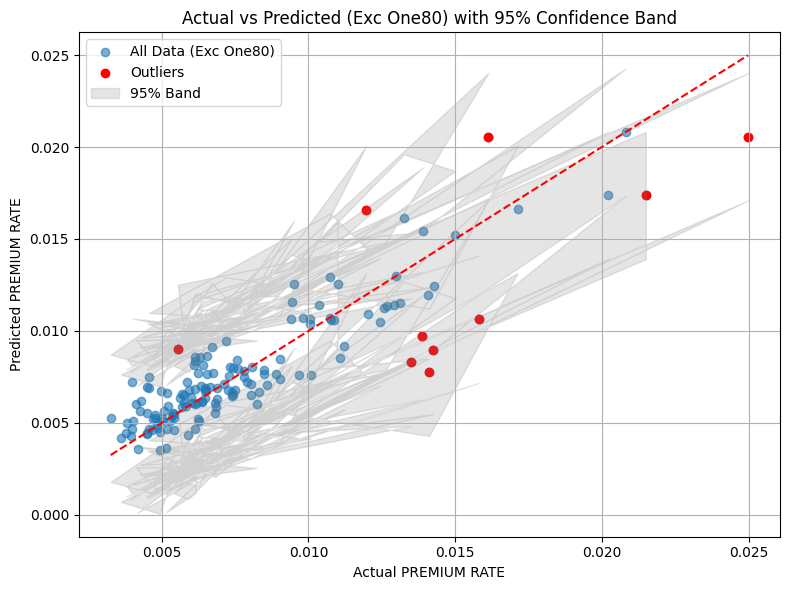

In [230]:
# Plot (Exc One80)
plt.figure(figsize=(8,6))
plt.scatter(y_no_one80, y_pred_no_one80, alpha=0.6, label='All Data (Exc One80)')
plt.scatter(y_no_one80[outliers_mask_no_one80], y_pred_no_one80[outliers_mask_no_one80],
            color='red', label='Outliers')
plt.plot([y_no_one80.min(), y_no_one80.max()],
         [y_no_one80.min(), y_no_one80.max()], 'r--')
plt.fill_between(y_no_one80, lower_bound_no_one80, upper_bound_no_one80,
                 color='gray', alpha=0.2, label='95% Band')
plt.xlabel("Actual PREMIUM RATE")
plt.ylabel("Predicted PREMIUM RATE")
plt.title("Actual vs Predicted (Exc One80) with 95% Confidence Band")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

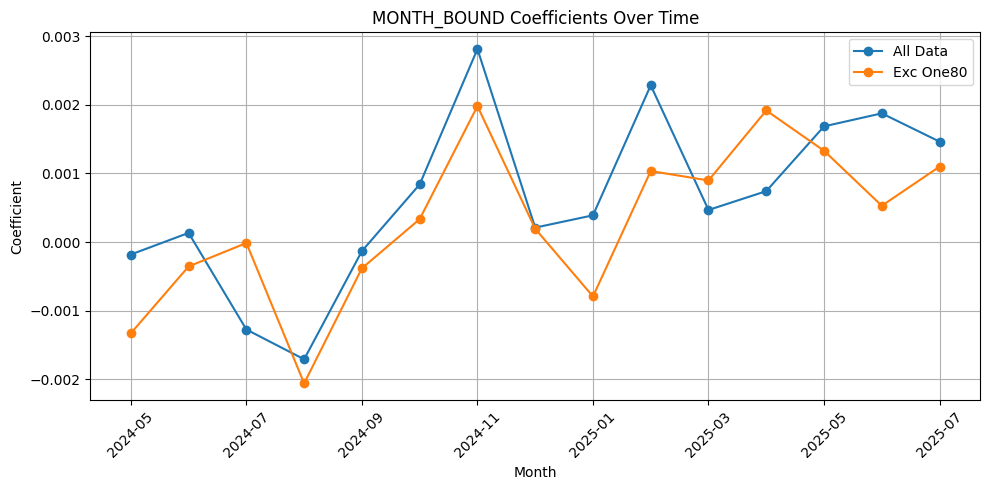

In [231]:
# Plot Monthly Coefficients (inc and exc One80)
def plot_month_bound_coefs():
    def extract_month_coefs(model):
        return {
            k.replace('MONTH_BOUND_', ''): v
            for k, v in model.params.items()
            if k.startswith('MONTH_BOUND_')
        }

    coefs_all = extract_month_coefs(models['Full Data'])
    coefs_no_one80 = extract_month_coefs(models['No One80'])

    df_coef = pd.DataFrame({
        'All Data': pd.Series(coefs_all),
        'Exc One80': pd.Series(coefs_no_one80)
    }).sort_index()

    df_coef.plot(marker='o', figsize=(10,5))
    plt.title("MONTH_BOUND Coefficients Over Time")
    plt.ylabel("Coefficient")
    plt.xlabel("Month")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_month_bound_coefs()